# OI heads: attention sufficiency tests

At output positions, OI heads attend to many targets (paired inputs, unpaired inputs, BOS, arrows).
Which target is **sufficient** for their function?

Test: for OI heads, at output positions only, zero all attention except to one target type.
Leave the head's behavior at all other positions completely intact.

In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '3'
import sys; sys.path.insert(0, '../..')
import torch, numpy as np, matplotlib.pyplot as plt, random, seaborn as sns
import pandas as pd, pickle
from collections import defaultdict
from tqdm import tqdm
from transformer_lens import HookedTransformer

try:
    from configs import MODEL_NAME
except ImportError:
    MODEL_NAME = 'meta-llama/Llama-3.2-3B'

%matplotlib inline
sns.set_context('notebook')

model = HookedTransformer.from_pretrained(MODEL_NAME, device='cuda', dtype=torch.float16)
model.eval()
n_layers = model.cfg.n_layers
n_heads  = model.cfg.n_heads
d_model  = model.cfg.d_model
PATTERN_FILTER = lambda name: 'attn.hook_pattern' in name

/home/cvllab/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-11 18:02:06.682778: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  3.33it/s]


Loaded pretrained model meta-llama/Llama-3.2-3B into HookedTransformer


In [2]:
def build_icl_prompt(demo_pairs, query_input):
    lines = [f'{inp} → {out}' for inp, out in demo_pairs]
    lines.append(f'{query_input} →')
    return '\n'.join(lines)

def find_per_demo_positions(model, prompt, demos):
    tokens = model.to_tokens(prompt, prepend_bos=True)[0]
    full_decoded = model.tokenizer.decode(tokens)
    char_to_tok = []
    for i in range(len(tokens)):
        s = model.tokenizer.decode([tokens[i].item()])
        char_to_tok.extend([i] * len(s))

    def span_to_toks(start, end):
        if start < 0 or end > len(char_to_tok): return []
        return sorted(set(char_to_tok[start:end]))

    result = []
    search_from = 0
    for inp, out in demos:
        demo = {'input_positions': [], 'output_positions': []}
        inp_s, out_s = str(inp), str(out)
        idx = full_decoded.find(inp_s, search_from)
        if idx >= 0:
            demo['input_positions'] = span_to_toks(idx, idx + len(inp_s))
            search_from = idx + len(inp_s)
        arrow = full_decoded.find('→', search_from)
        if arrow >= 0:
            oidx = full_decoded.find(out_s, arrow)
            if oidx >= 0:
                demo['output_positions'] = span_to_toks(oidx, oidx + len(out_s))
                search_from = oidx + len(out_s)
        result.append(demo)
    return result

@torch.no_grad()
def check_correct_multitoken(model, tokens, expected, max_new_tokens=20, hooks=None):
    target = expected.strip()
    generated = []
    cur = tokens.clone()
    for _ in range(max_new_tokens):
        if hooks:
            logits = model.run_with_hooks(cur, fwd_hooks=hooks)[0, -1]
        else:
            logits = model(cur)[0, -1]
        nt = logits.argmax().item()
        generated.append(nt)
        cur = torch.cat([cur, torch.tensor([[nt]], device=cur.device)], dim=1)
        decoded = model.tokenizer.decode(generated).strip()
        if decoded == target:
            return 1
        if len(decoded) >= len(target):
            return 0
        if decoded and not target.startswith(decoded):
            return 0
    return int(model.tokenizer.decode(generated).strip() == target)

def heads_by_layer(head_list):
    d = defaultdict(list)
    for L, h in head_list: d[L].append(h)
    return d

def make_ablation_hooks(hbl):
    hooks = []
    for L, h_list in hbl.items():
        def hook(z, hook, _hl=h_list):
            for h in _hl: z[0, :, h, :] = 0
            return z
        hooks.append((f'blocks.{L}.attn.hook_z', hook))
    return hooks

top10pct_n = max(1, int(0.10 * n_layers * n_heads))
all_pairs = [(L, h) for L in range(n_layers) for h in range(n_heads)]

In [3]:
CONSONANTS = 'bdfghjklmnprstvwz'
VOWELS = 'aeiou'

def make_nonsense(length, rng):
    pattern = [CONSONANTS, VOWELS] * (length // 2 + 1)
    return ''.join(rng.choice(p) for p in pattern[:length])

def _gen_nonce(rng, transform_fn, word_len=5):
    words = []
    while len(set(words)) < 11:
        words = [make_nonsense(word_len, rng) for _ in range(11)]
    demo_pairs = [(w, transform_fn(w)) for w in words[:10]]
    qi = words[10]
    return demo_pairs, qi, transform_fn(qi)

def gen_repetition(rng):    return _gen_nonce(rng, lambda x: x + x)
def gen_prepend_first(rng): return _gen_nonce(rng, lambda x: x[0] + x)
def gen_append_last(rng):   return _gen_nonce(rng, lambda x: x + x[-1])
def gen_drop_first(rng):    return _gen_nonce(rng, lambda x: x[1:])
def gen_drop_last(rng):     return _gen_nonce(rng, lambda x: x[:-1])
def gen_reverse(rng):       return _gen_nonce(rng, lambda x: x[::-1])
def gen_swap_ends(rng):     return _gen_nonce(rng, lambda x: x[-1] + x[1:-1] + x[0])
def gen_rotate_left(rng):   return _gen_nonce(rng, lambda x: x[1:] + x[0])
def gen_suffix_ed(rng):     return _gen_nonce(rng, lambda x: x + 'ed')
def gen_double_vowels(rng):
    return _gen_nonce(rng, lambda x: ''.join(c * 2 if c in VOWELS else c for c in x))

def _gen_arith(rng, fn, lo, hi):
    pool = list(range(lo, hi + 1))
    rng.shuffle(pool)
    nums = pool[:11]
    demo_pairs = [(str(n), str(fn(n))) for n in nums[:10]]
    qi = str(nums[10])
    return demo_pairs, qi, str(fn(nums[10]))

def gen_add_3(rng):       return _gen_arith(rng, lambda x: x + 3, 1, 50)
def gen_add_7(rng):       return _gen_arith(rng, lambda x: x + 7, 1, 50)
def gen_add_13(rng):      return _gen_arith(rng, lambda x: x + 13, 1, 50)
def gen_mul_2(rng):       return _gen_arith(rng, lambda x: 2*x, 1, 50)
def gen_mul_3(rng):       return _gen_arith(rng, lambda x: 3*x, 1, 30)
def gen_mul_5(rng):       return _gen_arith(rng, lambda x: 5*x, 1, 20)
def gen_mul_10(rng):      return _gen_arith(rng, lambda x: 10*x, 1, 20)
def gen_mul_2_add_1(rng): return _gen_arith(rng, lambda x: 2*x + 1, 1, 50)
def gen_mul_3_add_2(rng): return _gen_arith(rng, lambda x: 3*x + 2, 1, 30)
def gen_mul_2_sub_1(rng): return _gen_arith(rng, lambda x: 2*x - 1, 1, 50)

TASK_GENERATORS = {
    'repetition': gen_repetition, 'prepend_first': gen_prepend_first,
    'append_last': gen_append_last, 'drop_first': gen_drop_first,
    'drop_last': gen_drop_last, 'reverse': gen_reverse,
    'swap_ends': gen_swap_ends, 'rotate_left': gen_rotate_left,
    'suffix_ed': gen_suffix_ed, 'double_vowels': gen_double_vowels,
    'add_3': gen_add_3, 'add_7': gen_add_7, 'add_13': gen_add_13,
    'mul_2': gen_mul_2, 'mul_3': gen_mul_3, 'mul_5': gen_mul_5,
    'mul_10': gen_mul_10, 'mul_2_add_1': gen_mul_2_add_1,
    'mul_3_add_2': gen_mul_3_add_2, 'mul_2_sub_1': gen_mul_2_sub_1,
}
TASK_NAMES = list(TASK_GENERATORS.keys())
NONCE_TASKS = TASK_NAMES[:10]
ARITH_TASKS = TASK_NAMES[10:]
print(f'{len(NONCE_TASKS)} nonce tasks, {len(ARITH_TASKS)} arithmetic tasks')

10 nonce tasks, 10 arithmetic tasks


In [4]:
import os, pickle
SAVE_PATH = 'filtered_prompts.pkl'

if os.path.exists(SAVE_PATH):
    print(f'Loading filtered prompts from {SAVE_PATH}...')
    with open(SAVE_PATH, 'rb') as f:
        saved = pickle.load(f)
    TASKS = saved['TASKS']
    TASK_NAMES_ACTIVE = saved['TASK_NAMES_ACTIVE']
    print(f'Loaded {len(TASK_NAMES_ACTIVE)} active tasks')
    for name in TASK_NAMES_ACTIVE:
        print(f'  {name:<18s} n={len(TASKS[name])}')
else:
    raise FileNotFoundError('Run icl_tasks_v2.ipynb first to generate filtered_prompts.pkl')

nonce_active = [n for n in NONCE_TASKS if n in TASK_NAMES_ACTIVE]
arith_active = [n for n in ARITH_TASKS if n in TASK_NAMES_ACTIVE]
n_t = len(TASK_NAMES_ACTIVE)
n_cols = 4
n_rows = int(np.ceil(n_t / n_cols))

Loading filtered prompts from filtered_prompts.pkl...
Loaded 20 active tasks
  repetition         n=50
  prepend_first      n=50
  append_last        n=50
  drop_first         n=50
  drop_last          n=50
  reverse            n=12
  swap_ends          n=13
  rotate_left        n=42
  suffix_ed          n=50
  double_vowels      n=50
  add_3              n=50
  add_7              n=50
  add_13             n=50
  mul_2              n=50
  mul_3              n=50
  mul_5              n=50
  mul_10             n=50
  mul_2_add_1        n=50
  mul_3_add_2        n=35
  mul_2_sub_1        n=50


## Score and select OI heads

In [5]:
def score_oi_heads(prompts_data, desc='OI Scoring'):
    num_sum  = np.zeros((n_layers, n_heads), dtype=np.float64)
    base_sum = np.zeros((n_layers, n_heads), dtype=np.float64)
    cnt = 0
    for pdata in tqdm(prompts_data, desc=desc, leave=False):
        demos = pdata['demo_pairs']
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        seq_len = tokens.shape[1]
        per_demo = find_per_demo_positions(model, pdata['prompt'], demos)
        all_in = set(); all_out = set()
        for d in per_demo:
            for p in d.get('input_positions', []):  all_in.add(p)
            for p in d.get('output_positions', []): all_out.add(p)
        num_mask = torch.zeros(seq_len, seq_len)
        for d in per_demo:
            for op in d.get('output_positions', []):
                for ip in d.get('input_positions', []):
                    num_mask[op, ip] = 1.0
        base_mask = torch.zeros(seq_len, seq_len)
        ins_list = sorted(all_in)
        for q in range(seq_len):
            if q in all_out: continue
            for ik in ins_list:
                if ik <= q: base_mask[q, ik] = 1.0
        n_num = int(num_mask.sum().item()); n_base = int(base_mask.sum().item())
        if n_num == 0 or n_base == 0: continue
        with torch.no_grad():
            _, cache = model.run_with_cache(tokens, names_filter=PATTERN_FILTER)
        for L in range(n_layers):
            patt = cache['pattern', L][0].cpu().float()
            num_sum[L, :]  += (patt * num_mask).sum(dim=(1, 2)).numpy() / n_num
            base_sum[L, :] += (patt * base_mask).sum(dim=(1, 2)).numpy() / n_base
        cnt += 1
        del cache; torch.cuda.empty_cache()
    return (num_sum - base_sum) / max(cnt, 1)

print('Scoring OI heads per task...')
task_oi_scores = {}
for name in TASK_NAMES_ACTIVE:
    task_oi_scores[name] = score_oi_heads(TASKS[name], desc=name)

# Select top 10% per task
task_oi_top = {}
for name in TASK_NAMES_ACTIVE:
    sc = task_oi_scores[name]
    flat = sorted([(L, h, sc[L, h]) for L in range(n_layers) for h in range(n_heads)],
                  key=lambda x: -x[2])
    task_oi_top[name] = [(L, h) for L, h, _ in flat[:top10pct_n]]

print('OI scoring complete')

Scoring OI heads per task...


OI scoring complete


## Sufficiency knockout functions

At output positions: zero all attention except to the specified target.
Renormalize. Leave non-output rows completely intact.

In [6]:
def make_attn_knockout_hooks(head_list, knockout_fn):
    hbl = defaultdict(list)
    for L, h in head_list:
        hbl[L].append(h)
    hooks = []
    for L, h_list in hbl.items():
        def hook(pattern, hook, _hl=h_list, _ko=knockout_fn):
            for h in _hl:
                pattern[0, h] = _ko(pattern[0, h])
            return pattern
        hooks.append((f'blocks.{L}.attn.hook_pattern', hook))
    return hooks

_knockout_positions = {}

def set_knockout_positions(per_demo, seq_len, pdata=None):
    demos = []
    all_out = set()
    all_in = set()
    per_demo_arrows = {}
    for d_idx, d in enumerate(per_demo):
        ins = d.get('input_positions', [])
        outs = d.get('output_positions', [])
        demos.append({'in': ins, 'out': outs})
        all_out.update(outs)
        all_in.update(ins)
        if ins and outs:
            per_demo_arrows[d_idx] = list(range(max(ins) + 1, min(outs)))
        else:
            per_demo_arrows[d_idx] = []
    all_arrow = []
    for v in per_demo_arrows.values():
        all_arrow.extend(v)

    # Find query positions
    query_pos = []
    if pdata is not None:
        query_str = str(pdata.get('query_input', ''))
        if query_str:
            toks = model.to_tokens(pdata['prompt'], prepend_bos=True)[0]
            full_decoded = model.tokenizer.decode(toks)
            last_arrow = full_decoded.rfind('→')
            qi = full_decoded.rfind(query_str, 0, last_arrow)
            if qi >= 0:
                char_to_tok = []
                for i in range(len(toks)):
                    s = model.tokenizer.decode([toks[i].item()])
                    char_to_tok.extend([i] * len(s))
                for ci in range(qi, min(qi + len(query_str), len(char_to_tok))):
                    query_pos.append(char_to_tok[ci])
                query_pos = sorted(set(query_pos))

    _knockout_positions['demos'] = demos
    _knockout_positions['out_all'] = sorted(all_out)
    _knockout_positions['in_all'] = sorted(all_in)
    _knockout_positions['arrow_pos'] = sorted(set(all_arrow))
    _knockout_positions['per_demo_arrows'] = per_demo_arrows
    _knockout_positions['query_pos'] = query_pos
    _knockout_positions['seq_len'] = seq_len
    _knockout_positions['final'] = seq_len - 1


def _keep_only_at_output_rows(pattern, keep_mask_fn):
    """At output rows: zero everything, restore only entries where keep_mask_fn returns True.
    Renormalize output rows. Leave all other rows untouched."""
    p = pattern.clone()
    out_all = set(o for d in _knockout_positions['demos'] for o in d['out'])
    for o in out_all:
        original_row = pattern[o].clone()
        p[o] = 0
        for k in range(pattern.shape[-1]):
            if keep_mask_fn(o, k):
                p[o, k] = original_row[k]
        s = p[o].sum()
        if s > 0:
            p[o] = p[o] / s
        else:
            p[o, o] = 1.0  # self-attend fallback
    return p

# --- Sufficiency conditions ---

def suff_keep_paired_input(pattern):
    """At output rows, keep only paired input attention."""
    paired = {}
    for d in _knockout_positions['demos']:
        for o in d['out']:
            paired[o] = set(d['in'])
    return _keep_only_at_output_rows(pattern,
        lambda o, k: k in paired.get(o, set()))

def suff_keep_unpaired_input(pattern):
    """At output rows, keep only unpaired (cross-demo) input attention."""
    demos = _knockout_positions['demos']
    unpaired = {}
    for d_idx, d in enumerate(demos):
        other_in = set()
        for j_idx, j in enumerate(demos):
            if j_idx != d_idx:
                other_in.update(j['in'])
        for o in d['out']:
            unpaired[o] = other_in
    return _keep_only_at_output_rows(pattern,
        lambda o, k: k in unpaired.get(o, set()))

def suff_keep_all_input(pattern):
    """At output rows, keep attention to ALL input positions (paired + unpaired)."""
    in_all = set(_knockout_positions['in_all'])
    return _keep_only_at_output_rows(pattern,
        lambda o, k: k in in_all)

def suff_keep_bos(pattern):
    """At output rows, keep only BOS attention."""
    return _keep_only_at_output_rows(pattern,
        lambda o, k: k == 0)

def suff_keep_arrow(pattern):
    """At output rows, keep only arrow attention."""
    arrows = set(_knockout_positions['arrow_pos'])
    return _keep_only_at_output_rows(pattern,
        lambda o, k: k in arrows)

def suff_keep_other_output(pattern):
    """At output rows, keep only attention to other output positions."""
    out_all = set(o for d in _knockout_positions['demos'] for o in d['out'])
    return _keep_only_at_output_rows(pattern,
        lambda o, k: k in out_all and k != o)

SUFFICIENCY_FNS = {
    'keep paired in':    suff_keep_paired_input,
    'keep unpaired in':  suff_keep_unpaired_input,
    'keep all in':       suff_keep_all_input,
    'keep BOS':          suff_keep_bos,
    'keep arrow':        suff_keep_arrow,
    'keep other out':    suff_keep_other_output,
}

## Sufficiency experiment

For OI heads: at output positions, restrict attention to only one target type.
Compare against same restriction on random heads.
If accuracy survives for OI heads but not random → that target is specifically
sufficient for the OI function.

In [7]:
SUFF_KEYS = ['unablated', 'full_oi_ablation'] + \
            [f'oi_{k}' for k in SUFFICIENCY_FNS] + \
            [f'rand_{k}' for k in SUFFICIENCY_FNS]

suff_results = {name: {k: [] for k in SUFF_KEYS} for name in TASK_NAMES_ACTIVE}

for name in TASK_NAMES_ACTIVE:
    oi_top = task_oi_top[name]
    oi_set = set(oi_top)
    rng_r = random.Random(hash(name + '_suff') % 10**6)
    rand_heads = rng_r.sample([p for p in all_pairs if p not in oi_set], top10pct_n)

    full_abl = make_ablation_hooks(heads_by_layer(oi_top))
    suff_hooks = {}
    for sname, sfn in SUFFICIENCY_FNS.items():
        suff_hooks[f'oi_{sname}'] = make_attn_knockout_hooks(oi_top, sfn)
        suff_hooks[f'rand_{sname}'] = make_attn_knockout_hooks(rand_heads, sfn)

    for pdata in tqdm(TASKS[name], desc=f'{name} suff'):
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        ans = pdata['query_output']
        seq_len = tokens.shape[1]
        per_demo = find_per_demo_positions(model, pdata['prompt'], pdata['demo_pairs'])
        set_knockout_positions(per_demo, seq_len, pdata)

        suff_results[name]['unablated'].append(
            check_correct_multitoken(model, tokens, ans))
        suff_results[name]['full_oi_ablation'].append(
            check_correct_multitoken(model, tokens, ans, hooks=full_abl))
        for sk, hooks in suff_hooks.items():
            suff_results[name][sk].append(
                check_correct_multitoken(model, tokens, ans, hooks=hooks))
        torch.cuda.empty_cache()

    for k in SUFF_KEYS:
        suff_results[name][k] = np.array(suff_results[name][k])

print('Sufficiency experiment complete')

repetition suff:   0%|          | 0/50 [00:22<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
suff_labels = {'unablated': 'Unablated', 'full_oi_ablation': 'Full OI\nablation'}
for k in SUFFICIENCY_FNS:
    suff_labels[f'oi_{k}'] = f'OI\n{k}'
    suff_labels[f'rand_{k}'] = f'Rand\n{k}'
suff_order = [suff_labels[k] for k in SUFF_KEYS]

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
for ax, (group_label, task_list) in zip(axes, [
    ('Nonce tasks', nonce_active), ('Arithmetic tasks', arith_active),
    ('All tasks', TASK_NAMES_ACTIVE)]):
    rows = []
    for k in SUFF_KEYS:
        for name in task_list:
            for v in suff_results[name][k]:
                rows.append({'Condition': suff_labels[k], 'Accuracy': v})
    df = pd.DataFrame(rows)
    palette = ['tab:blue', 'black'] + \
              ['tab:red'] * len(SUFFICIENCY_FNS) + ['lightgray'] * len(SUFFICIENCY_FNS)
    sns.barplot(data=df, x='Condition', y='Accuracy', order=suff_order,
                palette=palette, errorbar=('ci', 95), linewidth=0, ax=ax)
    ax.set_ylim(0, 1.05); ax.set_xlabel('')
    ax.set_title(f'{group_label}', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=35, ha='right', fontsize=6)
fig.suptitle('Attention sufficiency at output positions: OI (red) vs random (gray), 95% CI', fontsize=13)
plt.tight_layout(); plt.show()

print(f'\n{"Condition":<22s} {"OI acc":>8s} {"Rand acc":>9s} {"Specific":>9s}')
print('-' * 52)
for k in SUFFICIENCY_FNS:
    oi_all = np.concatenate([suff_results[name][f'oi_{k}'] for name in TASK_NAMES_ACTIVE])
    rand_all = np.concatenate([suff_results[name][f'rand_{k}'] for name in TASK_NAMES_ACTIVE])
    print(f'{k:<22s} {oi_all.mean():>8.3f} {rand_all.mean():>9.3f} '
          f'{rand_all.mean()-oi_all.mean():>+9.3f}')

## Per-task sufficiency

In [ ]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = np.array(axes).flatten()
for ax, name in zip(axes, TASK_NAMES_ACTIVE):
    rows = [{'Condition': suff_labels[k], 'Accuracy': v}
            for k in SUFF_KEYS for v in suff_results[name][k]]
    df = pd.DataFrame(rows)
    palette = ['tab:blue', 'black'] + \
              ['tab:red'] * len(SUFFICIENCY_FNS) + ['lightgray'] * len(SUFFICIENCY_FNS)
    sns.barplot(data=df, x='Condition', y='Accuracy', order=suff_order,
                palette=palette, errorbar=('ci', 95), linewidth=0, ax=ax)
    ax.set_ylim(0, 1.05); ax.set_xlabel(''); ax.set_title(name, fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.get_xticklabels(), rotation=35, ha='right', fontsize=5)
for ax in axes[n_t:]: ax.set_visible(False)
fig.suptitle('Per-task sufficiency: OI (red) vs random (gray), 95% CI', fontsize=13)
plt.tight_layout(); plt.show()

## Necessity experiment: exhaustive attention knockout

For each source→target pair, zero those attention entries in OI heads.
Compare against same knockout on random heads.
Covers all 24 possible causal attention patterns across 5 source types.

In [13]:
# === Necessity knockout functions: zero specific source→target attention ===

def _zero_and_renorm(pattern, src_positions, tgt_positions):
    """Zero attention from src to tgt positions, renormalize src rows."""
    p = pattern.clone()
    for s in src_positions:
        for t in tgt_positions:
            if t < p.shape[-1]:
                p[s, t] = 0
        row_sum = p[s].sum()
        if row_sum > 0: p[s] = p[s] / row_sum
        else: p[s, s] = 1.0
    return p

def _get_query_positions():
    return _knockout_positions.get('query_pos', [])

# --- O row: knockouts at output positions ---

def nec_O_bos(pattern):
    out_all = [o for d in _knockout_positions['demos'] for o in d['out']]
    return _zero_and_renorm(pattern, out_all, [0])

def nec_O_I_paired(pattern):
    p = pattern.clone()
    for d in _knockout_positions['demos']:
        for o in d['out']:
            for i in d['in']:
                p[o, i] = 0
        for o in d['out']:
            s = p[o].sum()
            if s > 0: p[o] = p[o] / s
            else: p[o, o] = 1.0
    return p

def nec_O_I_unpaired(pattern):
    p = pattern.clone()
    demos = _knockout_positions['demos']
    for d_idx, d in enumerate(demos):
        other_in = []
        for j_idx, j in enumerate(demos):
            if j_idx != d_idx: other_in.extend(j['in'])
        for o in d['out']:
            for i in other_in: p[o, i] = 0
            s = p[o].sum()
            if s > 0: p[o] = p[o] / s
            else: p[o, o] = 1.0
    return p

def nec_O_O_cross(pattern):
    p = pattern.clone()
    demos = _knockout_positions['demos']
    for d_idx, d in enumerate(demos):
        other_out = []
        for j_idx, j in enumerate(demos):
            if j_idx != d_idx: other_out.extend(j['out'])
        for o in d['out']:
            for oo in other_out:
                if oo < o: p[o, oo] = 0
            s = p[o].sum()
            if s > 0: p[o] = p[o] / s
            else: p[o, o] = 1.0
    return p

def nec_O_arr_same(pattern):
    p = pattern.clone()
    demos = _knockout_positions['demos']
    arrows = _knockout_positions.get('per_demo_arrows', {})
    for d_idx, d in enumerate(demos):
        d_arrows = arrows.get(d_idx, [])
        for o in d['out']:
            for a in d_arrows: p[o, a] = 0
            s = p[o].sum()
            if s > 0: p[o] = p[o] / s
            else: p[o, o] = 1.0
    return p

def nec_O_arr_cross(pattern):
    p = pattern.clone()
    demos = _knockout_positions['demos']
    arrows = _knockout_positions.get('per_demo_arrows', {})
    for d_idx, d in enumerate(demos):
        other_arrows = []
        for j_idx in range(len(demos)):
            if j_idx != d_idx: other_arrows.extend(arrows.get(j_idx, []))
        for o in d['out']:
            for a in other_arrows:
                if a < o: p[o, a] = 0
            s = p[o].sum()
            if s > 0: p[o] = p[o] / s
            else: p[o, o] = 1.0
    return p

# --- F row: knockouts at final position ---

def nec_F_bos(pattern):
    return _zero_and_renorm(pattern, [_knockout_positions['final']], [0])

def nec_F_I(pattern):
    return _zero_and_renorm(pattern, [_knockout_positions['final']], _knockout_positions['in_all'])

def nec_F_O(pattern):
    return _zero_and_renorm(pattern, [_knockout_positions['final']], _knockout_positions['out_all'])

def nec_F_arr(pattern):
    return _zero_and_renorm(pattern, [_knockout_positions['final']], _knockout_positions['arrow_pos'])

def nec_F_Q(pattern):
    return _zero_and_renorm(pattern, [_knockout_positions['final']], _get_query_positions())

# --- Q row: knockouts at query position ---

def nec_Q_bos(pattern):
    return _zero_and_renorm(pattern, _get_query_positions(), [0])

def nec_Q_I(pattern):
    return _zero_and_renorm(pattern, _get_query_positions(), _knockout_positions['in_all'])

def nec_Q_O(pattern):
    return _zero_and_renorm(pattern, _get_query_positions(), _knockout_positions['out_all'])

def nec_Q_arr(pattern):
    return _zero_and_renorm(pattern, _get_query_positions(), _knockout_positions['arrow_pos'])

# --- I row: knockouts at input positions ---

def nec_I_bos(pattern):
    return _zero_and_renorm(pattern, _knockout_positions['in_all'], [0])

def nec_I_I_cross(pattern):
    p = pattern.clone()
    demos = _knockout_positions['demos']
    for d_idx, d in enumerate(demos):
        other_in = []
        for j_idx, j in enumerate(demos):
            if j_idx != d_idx: other_in.extend(j['in'])
        for i in d['in']:
            for oi in other_in:
                if oi < i: p[i, oi] = 0
            s = p[i].sum()
            if s > 0: p[i] = p[i] / s
            else: p[i, i] = 1.0
    return p

def nec_I_O_prev(pattern):
    p = pattern.clone()
    demos = _knockout_positions['demos']
    for d_idx, d in enumerate(demos):
        prev_out = []
        for j_idx in range(d_idx):
            prev_out.extend(demos[j_idx]['out'])
        for i in d['in']:
            for o in prev_out: p[i, o] = 0
            s = p[i].sum()
            if s > 0: p[i] = p[i] / s
            else: p[i, i] = 1.0
    return p

def nec_I_arr(pattern):
    p = pattern.clone()
    demos = _knockout_positions['demos']
    arrows = _knockout_positions.get('per_demo_arrows', {})
    for d_idx, d in enumerate(demos):
        prev_arrows = []
        for j_idx in range(d_idx + 1):
            prev_arrows.extend(arrows.get(j_idx, []))
        for i in d['in']:
            for a in prev_arrows:
                if a < i: p[i, a] = 0
            s = p[i].sum()
            if s > 0: p[i] = p[i] / s
            else: p[i, i] = 1.0
    return p

# --- arr row: knockouts at arrow positions ---

def nec_arr_bos(pattern):
    all_arrows = _knockout_positions['arrow_pos']
    return _zero_and_renorm(pattern, all_arrows, [0])

def nec_arr_I_same(pattern):
    p = pattern.clone()
    demos = _knockout_positions['demos']
    arrows = _knockout_positions.get('per_demo_arrows', {})
    for d_idx, d in enumerate(demos):
        d_arrows = arrows.get(d_idx, [])
        for a in d_arrows:
            for i in d['in']:
                if i < a: p[a, i] = 0
            s = p[a].sum()
            if s > 0: p[a] = p[a] / s
            else: p[a, a] = 1.0
    return p

def nec_arr_I_prev(pattern):
    p = pattern.clone()
    demos = _knockout_positions['demos']
    arrows = _knockout_positions.get('per_demo_arrows', {})
    for d_idx, d in enumerate(demos):
        d_arrows = arrows.get(d_idx, [])
        prev_in = []
        for j_idx in range(d_idx):
            prev_in.extend(demos[j_idx]['in'])
        for a in d_arrows:
            for i in prev_in: p[a, i] = 0
            s = p[a].sum()
            if s > 0: p[a] = p[a] / s
            else: p[a, a] = 1.0
    return p

def nec_arr_O_prev(pattern):
    p = pattern.clone()
    demos = _knockout_positions['demos']
    arrows = _knockout_positions.get('per_demo_arrows', {})
    for d_idx, d in enumerate(demos):
        d_arrows = arrows.get(d_idx, [])
        prev_out = []
        for j_idx in range(d_idx):
            prev_out.extend(demos[j_idx]['out'])
        for a in d_arrows:
            for o in prev_out: p[a, o] = 0
            s = p[a].sum()
            if s > 0: p[a] = p[a] / s
            else: p[a, a] = 1.0
    return p

def nec_arr_arr_prev(pattern):
    p = pattern.clone()
    arrows = _knockout_positions.get('per_demo_arrows', {})
    all_d_idxs = sorted(arrows.keys())
    for d_idx in all_d_idxs:
        d_arrows = arrows[d_idx]
        prev_arrows = []
        for j_idx in range(d_idx):
            prev_arrows.extend(arrows.get(j_idx, []))
        for a in d_arrows:
            for pa in prev_arrows: p[a, pa] = 0
            s = p[a].sum()
            if s > 0: p[a] = p[a] / s
            else: p[a, a] = 1.0
    return p

def make_batched_knockout_hooks(head_list, knockout_fns):
    """Apply different knockout fn to each batch element."""
    hbl = defaultdict(list)
    for L, h in head_list:
        hbl[L].append(h)
    hooks = []
    for L, h_list in hbl.items():
        def hook(pattern, hook, _hl=h_list, _fns=knockout_fns):
            for b, fn in enumerate(_fns):
                for h in _hl:
                    pattern[b, h] = fn(pattern[b, h])
            return pattern
        hooks.append((f'blocks.{L}.attn.hook_pattern', hook))
    return hooks

NECESSITY_FNS = {
    # O row
    'O→BOS':          nec_O_bos,
    'O→I paired':     nec_O_I_paired,
    'O→I unpaired':   nec_O_I_unpaired,
    'O→O cross':      nec_O_O_cross,
    'O→arr same':     nec_O_arr_same,
    'O→arr cross':    nec_O_arr_cross,
    # F row
    'F→BOS':          nec_F_bos,
    'F→I':            nec_F_I,
    'F→O':            nec_F_O,
    'F→arr':          nec_F_arr,
    'F→Q':            nec_F_Q,
    # Q row
    'Q→BOS':          nec_Q_bos,
    'Q→I':            nec_Q_I,
    'Q→O':            nec_Q_O,
    'Q→arr':          nec_Q_arr,
    # I row
    'I→BOS':          nec_I_bos,
    'I→I cross':      nec_I_I_cross,
    'I→O prev':       nec_I_O_prev,
    'I→arr':          nec_I_arr,
    # arr row
    'arr→BOS':        nec_arr_bos,
    'arr→I same':     nec_arr_I_same,
    'arr→I prev':     nec_arr_I_prev,
    'arr→O prev':     nec_arr_O_prev,
    'arr→arr prev':   nec_arr_arr_prev,
}
print(f'{len(NECESSITY_FNS)} necessity conditions defined')


24 necessity conditions defined


In [18]:
# === Run necessity experiment (batched by source row) ===

nec_fn_list = list(NECESSITY_FNS.values())
nec_name_list = list(NECESSITY_FNS.keys())
n_nec = len(nec_fn_list)

# Split into batches to avoid OOM (batch by source row)
row_groups = {
    'O': [k for k in nec_name_list if k.startswith('O')],
    'F': [k for k in nec_name_list if k.startswith('F')],
    'Q': [k for k in nec_name_list if k.startswith('Q')],
    'I': [k for k in nec_name_list if k.startswith('I')],
    'arr': [k for k in nec_name_list if k.startswith('arr')],
}

NEC_KEYS = ['unablated', 'full_oi_ablation'] + \
           [f'oi_{k}' for k in nec_name_list] + \
           [f'rand_{k}' for k in nec_name_list]

nec_results = {name: {k: [] for k in NEC_KEYS} for name in TASK_NAMES_ACTIVE}

for name in TASK_NAMES_ACTIVE:
    oi_top = task_oi_top[name]
    oi_set = set(oi_top)
    rng_r = random.Random(hash(name + '_nec') % 10**6)
    rand_heads = rng_r.sample([p for p in all_pairs if p not in oi_set], top10pct_n)
    full_abl = make_ablation_hooks(heads_by_layer(oi_top))

    for pdata in tqdm(TASKS[name], desc=f'{name} nec'):
        tokens = model.to_tokens(pdata['prompt'], prepend_bos=True)
        ans = pdata['query_output']
        seq_len = tokens.shape[1]
        per_demo = find_per_demo_positions(model, pdata['prompt'], pdata['demo_pairs'])
        set_knockout_positions(per_demo, seq_len, pdata)
        target = ans.strip()

        nec_results[name]['unablated'].append(
            check_correct_multitoken(model, tokens, ans))
        nec_results[name]['full_oi_ablation'].append(
            check_correct_multitoken(model, tokens, ans, hooks=full_abl))

        # Batch by source row
        for row_name, row_keys in row_groups.items():
            row_fns = [NECESSITY_FNS[k] for k in row_keys]
            n_row = len(row_fns)

            for prefix, head_list in [('oi', oi_top), ('rand', rand_heads)]:
                batch_hooks = make_batched_knockout_hooks(head_list, row_fns)
                batch_cur = tokens.expand(n_row, -1).clone()
                generated = [[] for _ in range(n_row)]
                acc_done = [False] * n_row
                acc_vals = [0] * n_row

                for _ in range(20):
                    if all(acc_done): break
                    with torch.no_grad():
                        logits = model.run_with_hooks(batch_cur, fwd_hooks=batch_hooks)
                    new_toks = []
                    for b in range(n_row):
                        nt = logits[b, -1].argmax().item()
                        generated[b].append(nt)
                        new_toks.append(nt)
                        if not acc_done[b]:
                            decoded = model.tokenizer.decode(generated[b]).strip()
                            if decoded == target:
                                acc_vals[b] = 1; acc_done[b] = True
                            elif len(decoded) >= len(target):
                                acc_done[b] = True
                            elif decoded and not target.startswith(decoded):
                                acc_done[b] = True
                    batch_cur = torch.cat([batch_cur,
                        torch.tensor(new_toks, device=batch_cur.device).unsqueeze(1)], dim=1)

                for ri, rk in enumerate(row_keys):
                    nec_results[name][f'{prefix}_{rk}'].append(acc_vals[ri])

        torch.cuda.empty_cache()

    for k in NEC_KEYS:
        nec_results[name][k] = np.array(nec_results[name][k])

print('Necessity experiment complete')


mul_2_sub_1 nec: 100%|██████████| 50/50 [06:22<00:00,  7.66s/it]

Necessity experiment complete


/tmp/ipykernel_2579850/591596330.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Condition', y='Accuracy', order=plot_order,
/tmp/ipykernel_2579850/591596330.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Condition', y='Accuracy', order=plot_order,
/tmp/ipykernel_2579850/591596330.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Condition', y='Accuracy', order=plot_order,
/tmp/ipykernel_2579850/591596330.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will

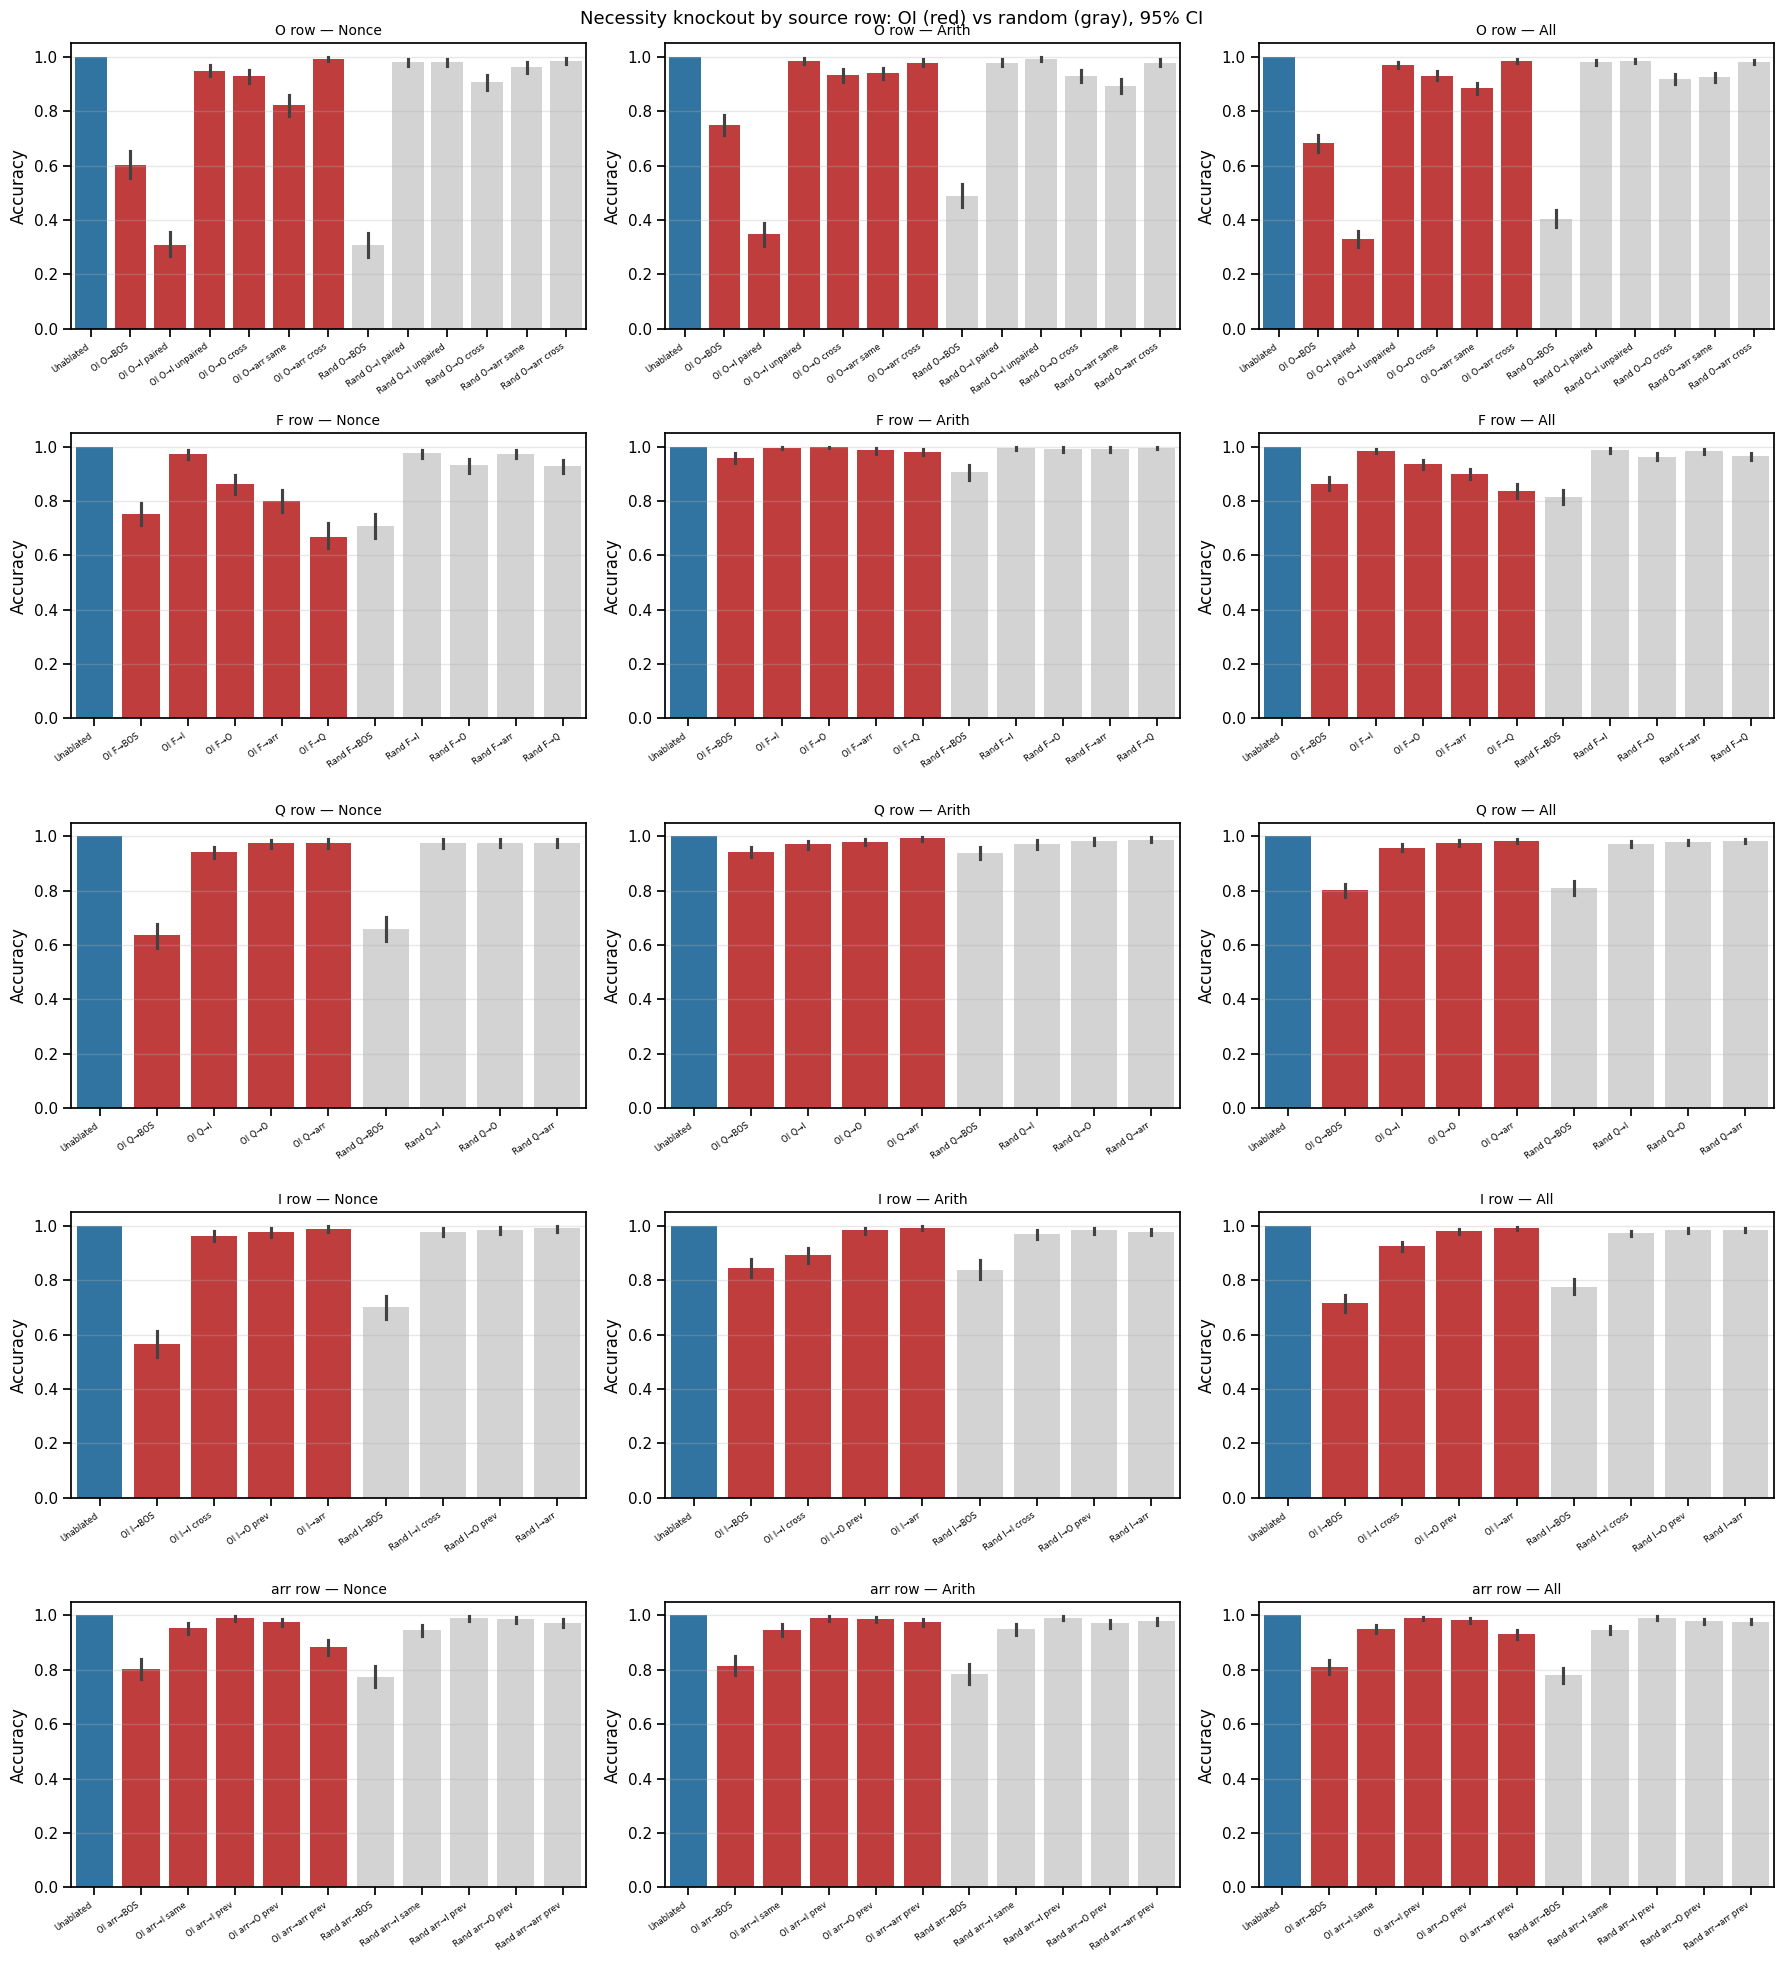

In [19]:
# === Plot necessity: grouped by source row ===

fig, axes = plt.subplots(len(row_groups), 3, figsize=(18, 4 * len(row_groups)))

for row_idx, (row_name, row_keys) in enumerate(row_groups.items()):
    plot_keys = ['unablated'] + [f'oi_{k}' for k in row_keys] + [f'rand_{k}' for k in row_keys]
    plot_labels = {'unablated': 'Unablated'}
    for k in row_keys:
        plot_labels[f'oi_{k}'] = f'OI {k}'
        plot_labels[f'rand_{k}'] = f'Rand {k}'
    plot_order = [plot_labels[k] for k in plot_keys]
    palette = ['tab:blue'] + ['tab:red'] * len(row_keys) + ['lightgray'] * len(row_keys)

    for col, (group_label, task_list) in enumerate([
        ('Nonce', nonce_active), ('Arith', arith_active), ('All', TASK_NAMES_ACTIVE)]):
        ax = axes[row_idx, col]
        rows = []
        for k in plot_keys:
            for name in task_list:
                for v in nec_results[name][k]:
                    rows.append({'Condition': plot_labels[k], 'Accuracy': v})
        df = pd.DataFrame(rows)
        sns.barplot(data=df, x='Condition', y='Accuracy', order=plot_order,
                    palette=palette, errorbar=('ci', 95), linewidth=0, ax=ax)
        ax.set_ylim(0, 1.05); ax.set_xlabel('')
        ax.set_title(f'{row_name} row — {group_label}', fontsize=10)
        ax.grid(True, alpha=0.3, axis='y')
        plt.setp(ax.get_xticklabels(), rotation=35, ha='right', fontsize=6)

fig.suptitle('Necessity knockout by source row: OI (red) vs random (gray), 95% CI', fontsize=13)
plt.tight_layout(); plt.show()


In [20]:
# === Specific effect for all necessity conditions ===

print(f'{"Condition":<22s} {"OI acc":>8s} {"Rand acc":>9s} {"Specific":>9s}')
print('-' * 52)
for k in nec_name_list:
    oi_all = np.concatenate([nec_results[name][f'oi_{k}'] for name in TASK_NAMES_ACTIVE])
    rand_all = np.concatenate([nec_results[name][f'rand_{k}'] for name in TASK_NAMES_ACTIVE])
    spec = rand_all.mean() - oi_all.mean()
    marker = ' ***' if abs(spec) > 0.2 else ' *' if abs(spec) > 0.1 else ''
    print(f'{k:<22s} {oi_all.mean():>8.3f} {rand_all.mean():>9.3f} {spec:>+9.3f}{marker}')


Condition                OI acc  Rand acc  Specific
----------------------------------------------------
O→BOS                     0.682     0.405    -0.277 ***
O→I paired                0.330     0.980    +0.650 ***
O→I unpaired              0.969     0.987    +0.018
O→O cross                 0.931     0.919    -0.012
O→arr same                0.886     0.925    +0.039
O→arr cross               0.986     0.982    -0.003
F→BOS                     0.864     0.814    -0.050
F→I                       0.984     0.986    +0.001
F→O                       0.935     0.962    +0.028
F→arr                     0.900     0.982    +0.082
F→Q                       0.837     0.965    +0.127 *
Q→BOS                     0.800     0.808    +0.008
Q→I                       0.958     0.972    +0.014
Q→O                       0.977     0.979    +0.002
Q→arr                     0.983     0.982    -0.001
I→BOS                     0.715     0.776    +0.061
I→I cross                 0.925     0.972    +0.048
I

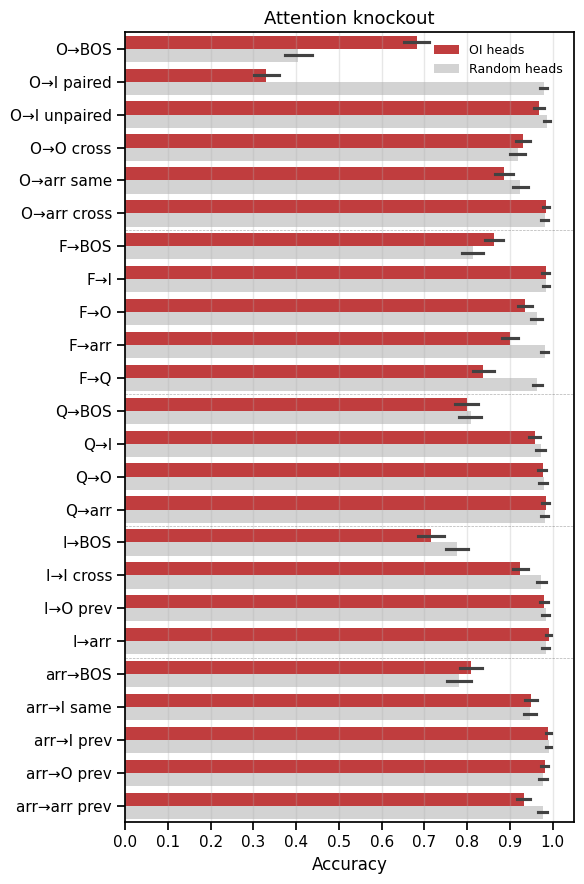

In [28]:
# === Attention knockout: horizontal bar plot ===
sns.set_context('notebook')

rows = []
for k in nec_name_list:
    oi_all = np.concatenate([nec_results[name][f'oi_{k}'] for name in TASK_NAMES_ACTIVE])
    rand_all = np.concatenate([nec_results[name][f'rand_{k}'] for name in TASK_NAMES_ACTIVE])
    for v in oi_all:
        rows.append({'Pattern': k, 'Type': 'OI heads', 'Accuracy': v})
    for v in rand_all:
        rows.append({'Pattern': k, 'Type': 'Random heads', 'Accuracy': v})
df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(6, 9))
sns.barplot(data=df, y='Pattern', x='Accuracy', hue='Type',
            hue_order=['OI heads', 'Random heads'],
            order=nec_name_list,
            palette={'OI heads': 'tab:red', 'Random heads': 'lightgray'},
            errorbar=('ci', 95), linewidth=0, orient='h', ax=ax)

# Row separators
row_bounds = [6, 11, 15, 19]
for start in row_bounds:
    ax.axhline(start - 0.5, color='black', lw=0.5, ls='--', alpha=0.3)

ax.set_xlim(0, 1.05)
ax.set_xticks(np.arange(0, 1.1, 0.1))
ax.set_ylabel('')
ax.legend(fontsize=9, loc='upper right', frameon=False)
ax.grid(True, alpha=0.3, axis='x')
ax.set_title('Attention knockout', fontsize=13)
ax.set_ylim(len(nec_name_list) - 0.5, -0.5)
plt.tight_layout(); plt.show()